SDGs 3: Good Health and Well-being

### Tujuan:
##### Mengklasifikasikan kondisi kesehatan janin menjadi:
##### 1 = Normal, 2 = Suspect, 3 = Pathological

### Kenapa penting?
##### - Membantu deteksi dini kondisi berbahaya pada janin
##### - Mendukung pengambilan keputusan medis

**IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, f1_score)
from imblearn.over_sampling import SMOTE

**LOAD DATA**

In [ ]:
import pandas as pd
df = pd.read_csv('fetal_health.csv')
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


**INFO STATISTIK**

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


**DISTRIBUSI TARGET**

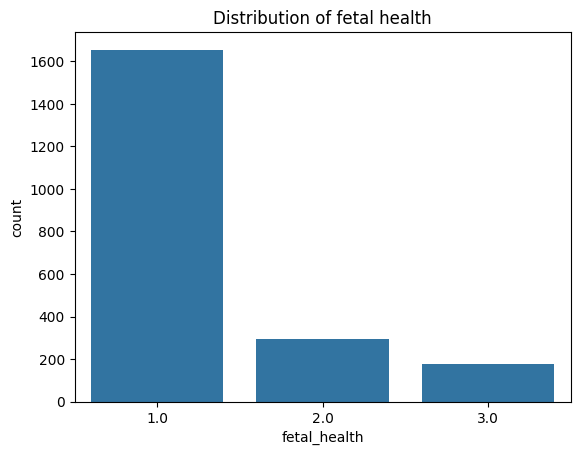

In [ ]:
sns.countplot(x='fetal_health', data=df)
plt.title('Distribution of fetal health')
plt.show()

**MISSING VALUE**

In [ ]:
df.isnull().sum()

,0
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


**SPLIT DATA**

In [ ]:
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

**TRAIN-TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y)

**SMOTE**

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

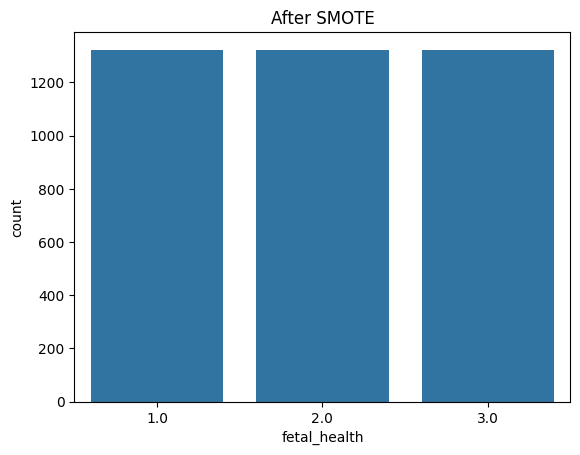

In [ ]:
sns.countplot(x=y_train_res)
plt.title("After SMOTE")
plt.show()

**TRAIN MODEL**

In [ ]:
rf = RandomForestClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000)
nb = GaussianNB()

rf.fit(X_train_res, y_train_res)
lr.fit(X_train_res, y_train_res)
nb.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GaussianNB()

In [ ]:
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('lr', lr), ('nb', nb)],
    voting='hard'
)

ensemble.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('lr', LogisticRegression(max_iter=1000)),
                             ('nb', GaussianNB())])

**PREDIKSI**

In [ ]:
rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)
nb_pred = nb.predict(X_test)
ensemble_pred = ensemble.predict(X_test)

**FUNC. CONFUSION MATRIX**

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Normal", "Suspect", "Pathological"]

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels)

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**FUNC. CLASSIFICATION**

In [ ]:
def show_classification_report(y_true, y_pred, title):
    print(f"\n=== {title} ===")
    print(classification_report(y_true, y_pred))

**EVALUATE MODEL**


=== Random Forest ===
              precision    recall  f1-score   support

         1.0       0.96      0.96      0.96       332
         2.0       0.76      0.76      0.76        59
         3.0       0.89      0.91      0.90        35

    accuracy                           0.93       426
   macro avg       0.87      0.88      0.88       426
weighted avg       0.93      0.93      0.93       426



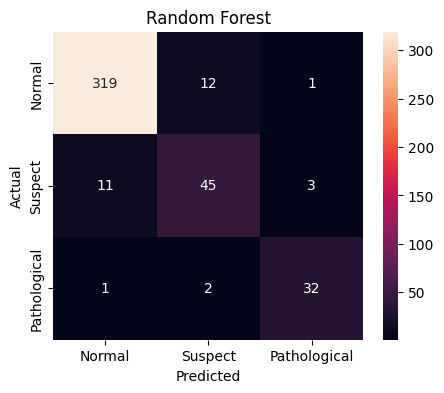


=== Logistic Regression ===
              precision    recall  f1-score   support

         1.0       0.97      0.78      0.86       332
         2.0       0.39      0.76      0.52        59
         3.0       0.66      0.83      0.73        35

    accuracy                           0.78       426
   macro avg       0.67      0.79      0.71       426
weighted avg       0.86      0.78      0.81       426



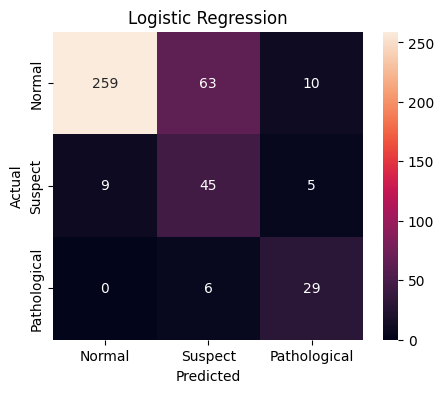


=== Naive Bayes ===
              precision    recall  f1-score   support

         1.0       0.98      0.75      0.85       332
         2.0       0.40      0.83      0.54        59
         3.0       0.43      0.60      0.50        35

    accuracy                           0.75       426
   macro avg       0.60      0.73      0.63       426
weighted avg       0.85      0.75      0.78       426



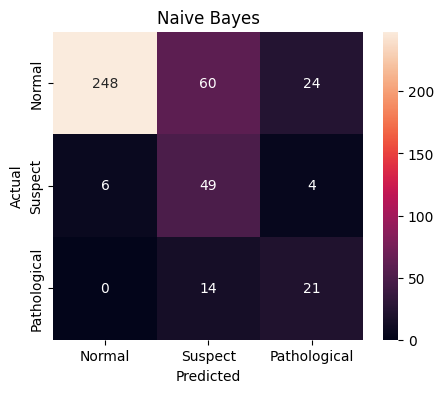


=== Ensemble ===
              precision    recall  f1-score   support

         1.0       0.98      0.86      0.91       332
         2.0       0.52      0.85      0.65        59
         3.0       0.72      0.83      0.77        35

    accuracy                           0.85       426
   macro avg       0.74      0.84      0.78       426
weighted avg       0.89      0.85      0.86       426



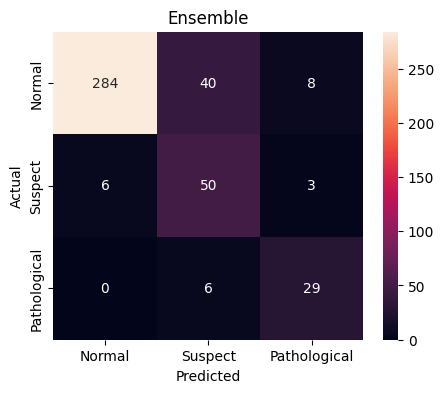

In [ ]:
models = {
    "Random Forest": rf_pred,
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "Ensemble": ensemble_pred
}

for name, pred in models.items():
    show_classification_report(y_test, pred, name)
    plot_confusion_matrix(y_test, pred, name)

**FEATURE IMPORTANCE - RF**

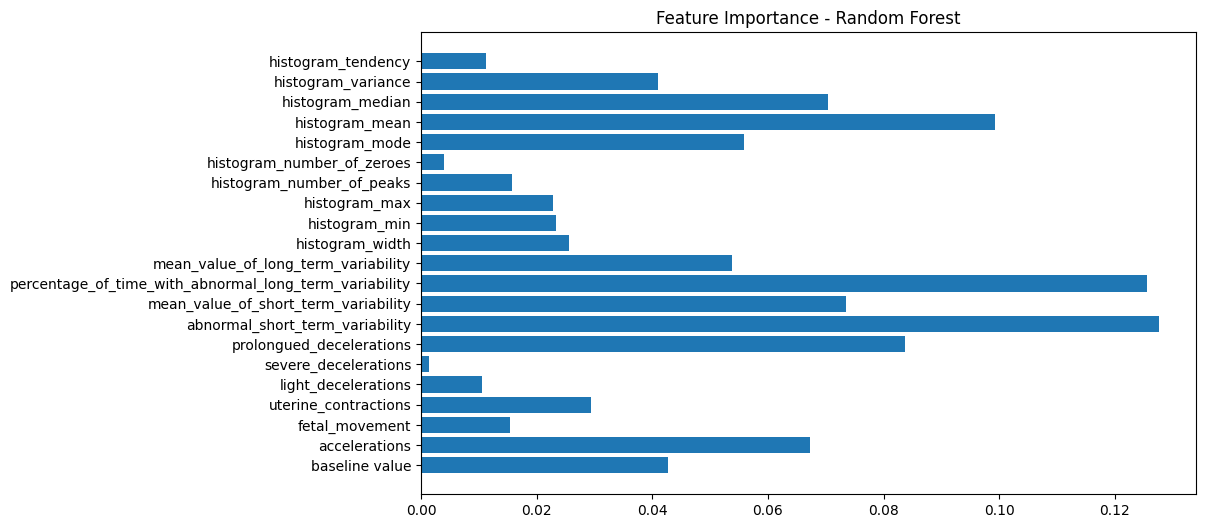

In [ ]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.show()

Hasil eksperimen menunjukkan bahwa metode ensemble Voting Classifier tidak selalu menghasilkan performa yang lebih baik dibandingkan model tunggal. Dalam penelitian ini, Random Forest sebagai model telah mampu menangkap kompleksitas data secara optimal, sehingga penambahan model lain seperti Logistic Regression dan Naive Bayes justru menurunkan performa akibat perbedaan karakteristik dan asumsi masing-masing model.